# <font color='blue'> Baseline Linear Regression </font>

In [3]:
# import datasets
import pandas as pd

df = pd.read_csv("../data/processed/housing_filtered.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## <font color='orange'> Using `median_income` to predict `median_house_value` </font>

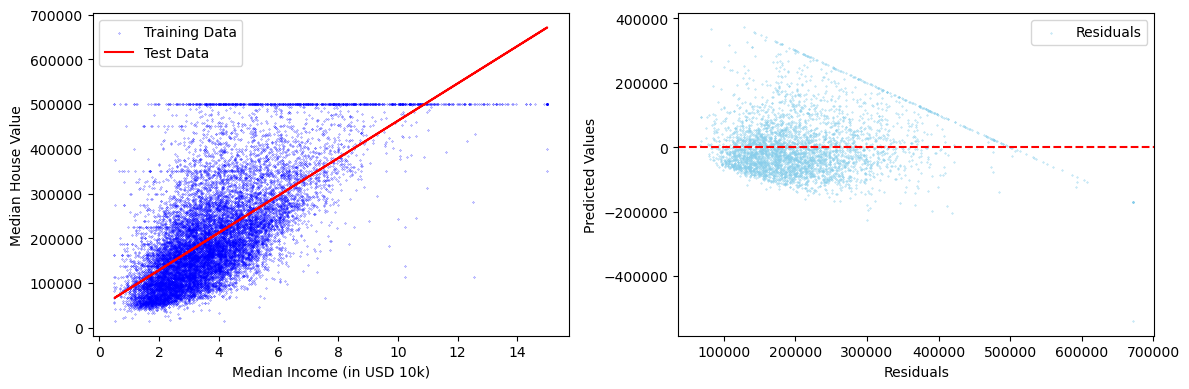

In [50]:
from sklearn.model_selection import train_test_split
from pandas.core.common import random_state
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# define the x and y variables
x = df[['median_income']]
y = df[['median_house_value']]

# split dataset for training and testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

# initialise linear regressor
regressor = LinearRegression()

# train the model
regressor.fit(x_train, y_train)

# test the model
y_test_pred = regressor.predict(x_test)
y_train_pred = regressor.predict(x_train)


# plot
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
axes[0].scatter(x_train, y_train, c='blue', s=0.05, label='Training Data')
axes[0].plot(x_test, y_test_pred, color='red', label='Test Data')
axes[0].set_xlabel('Median Income (in USD 10k)')
axes[0].set_ylabel('Median House Value')
axes[0].legend()

axes[1].scatter(y_test_pred, y_test - y_test_pred , c='skyblue', s=0.1, label='Residuals')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Predicted Values')
axes[1].legend()
plt.tight_layout()
plt.savefig("../figures/baseline_two_variable_regression.pdf")
plt.show()

## <font color='orange'> MAE (Mean Absolute Error) </font>

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_test_pred)
print(f"MAE:  {mae:.2f}")

MAE:  62549.25


## <font color='orange'> RMSE (Root Mean Squared Error) </font>

In [53]:
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")

RMSE: 83638.21


## <font color='orange'> $R^{2}$ (Coefficient of Determination) </font>

In [54]:
r2 = r2_score(y_test, y_test_pred)
print(f"R²:   {r2:.4f}")

R²:   0.4776


# <font color='blue'> Multivariable Linear Regression </font>

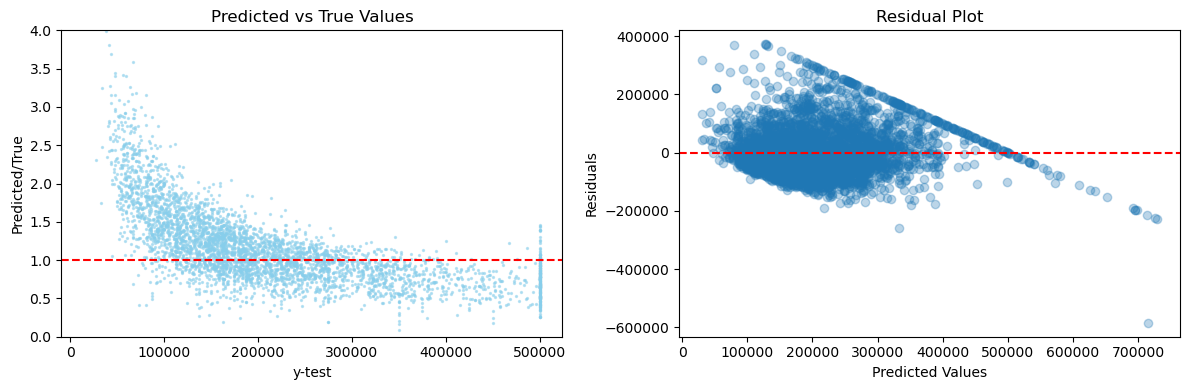

In [62]:
# define the x vector and y variable
x = df[['median_income', 'housing_median_age', 'total_rooms']]
y = df[['median_house_value']]

# split dataset for training and testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

# initialise linear regressor
regressor = LinearRegression()

# train the model
regressor.fit(x_train, y_train)

# test the model
y_test_pred = regressor.predict(x_test)
y_train_pred = regressor.predict(x_train)


# plot
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
axes[0].scatter(y_test, y_test_pred/y_test, c='skyblue', s=2, alpha=0.5)
axes[0].set_ylim(0,4)
axes[0].axhline(y=1, color='r', linestyle='--')
axes[0].set_xlabel("y-test")
axes[0].set_ylabel("Predicted/True")
axes[0].set_title("Predicted vs True Values")

axes[1].scatter(y_test_pred, y_test - y_test_pred, alpha=0.3)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel("Predicted Values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.savefig("../figures/baseline_multi_variable_regression.pdf")
plt.show()

## <font color='orange'> MAE (Mean Absolute Error) </font>

In [63]:
mae = mean_absolute_error(y_test, y_test_pred)
print(f"MAE:  {mae:.2f}")

MAE:  60254.02


## <font color='orange'> RMSE (Root Mean Squared Error) </font>

In [64]:
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")

RMSE: 80511.17


## <font color='orange'> $R^{2}$ (Coefficient of Determination) </font>

In [65]:
r2 = r2_score(y_test, y_test_pred)
print(f"R²:   {r2:.4f}")

R²:   0.5159


## Multivariable Linear Regression performs marginally better than the Simple Linear Regression Model